In [113]:
import matplotlib.pyplot as plt
import pandas as pd

from utils import data_utils as du
from utils import plot_utils as pu

cities = du.load_major_us_cities()
sf_raw = cities["sf_Existing_Buildings_Energy_Performance_Ordinance_Report_20260114"]
sea_raw = cities[
    "Seattle_Benchmarking_Performance_Ranges_by_Building_Type_2015-Present_20260125"
]
bos_raw = cities["boston_energy_raw"]

energy_data = du.load_data()
concurrent_df = du.concurrent_buildings(
    input_df=energy_data,
    start_year=2016,
    end_year=2023,
)

2026-02-21 18:46:53,399 [INFO] Loaded Seattle_Benchmarking_Performance_Ranges_by_Building_Type_2015-Present_20260125.csv → (34699, 46)
2026-02-21 18:46:53,511 [INFO] Loaded sf_Existing_Buildings_Energy_Performance_Ordinance_Report_20260114.csv → (28243, 34)
2026-02-21 18:47:26,568 [INFO] Loaded Boston_data folder → (35496, 96)


In [126]:
sf_chi = du.sf_to_chicago(sf_raw)
sea_chi = du.seattle_to_chicago(sea_raw)
sf_chi = sf_chi.assign(City="San Francisco")
sea_chi = sea_chi.assign(City="Seattle")
bos = du.harmonize_boston_columns(bos_raw)
bos_chi = du.boston_to_chicago(bos).assign(City="Boston")

In [131]:
bos_chi["Data Year"] = (
    pd.to_numeric(bos_chi["Data Year"], errors="coerce") - 1
).astype("Int64")

## Boston Data

In [132]:
metrics = ["Site EUI (kBtu/sq ft)", "ENERGY STAR Score"]

tmp = bos_chi.copy()
for c in metrics:
    tmp[c] = pd.to_numeric(tmp[c], errors="coerce")

summary_clean = (
    tmp.groupby("Data Year")[metrics].agg(["count", "mean", "median"]).round(2)
)

summary_clean

Site EUI (kBtu/sq ft)                  ENERGY STAR Score         \
                          count      mean median             count   mean   
Data Year                                                                   
2014                       1266    831.90  78.50               744  67.27   
2015                       1422    881.17  77.95               890  67.19   
2016                       1664  16870.60  70.70              1100  67.12   
2017                       1770    614.77  70.05              1166  66.88   
2018                       1669    194.28  71.50              1123  61.88   
2019                       1777    206.69  71.20              1205  62.72   
2020                       1296    144.92  60.80              1209   67.0   
2021                       2693     79.84  62.70              1661  68.22   
2022                       2691     80.63  65.20              1597  67.58   
2023                       3671     78.41  64.10              1974  67.65   
2024                       3678     76.49  63.30              1962  68.71   

                  
          median  
Data Year         
2014        77.0  
2015        77.0  
2016        77.0  
2017        76.0  
2018        68.0  
2019        69.0  
2020        75.0  
2021        76.0  
2022        75.0  
2023        75.0  
2024        76.0

In [133]:
bos_top = (
    bos_chi["Primary Property Type"]
    .dropna()
    .astype(str)
    .str.strip()
    .value_counts()
    .head(15)
)

bos_top

Primary Property Type
Multifamily Housing         10544
Office                       3872
K-12 School                  1652
College/University           1521
Hotel                         602
Residence Hall/Dormitory      531
Other                         483
Laboratory                    438
Fire Station                  435
CONDO MAIN                    330
Library                       296
Other - Recreation            278
Worship Facility              253
Self-Storage Facility         241
Medical Office                239
Name: count, dtype: int64

## Cities Comparisons

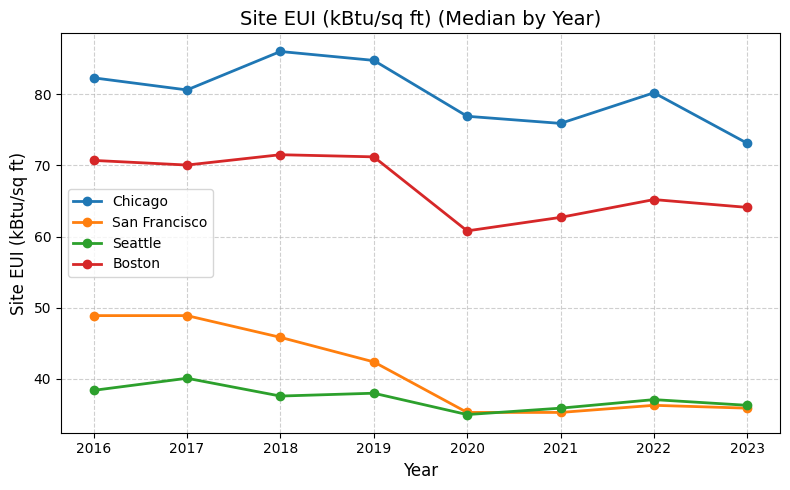

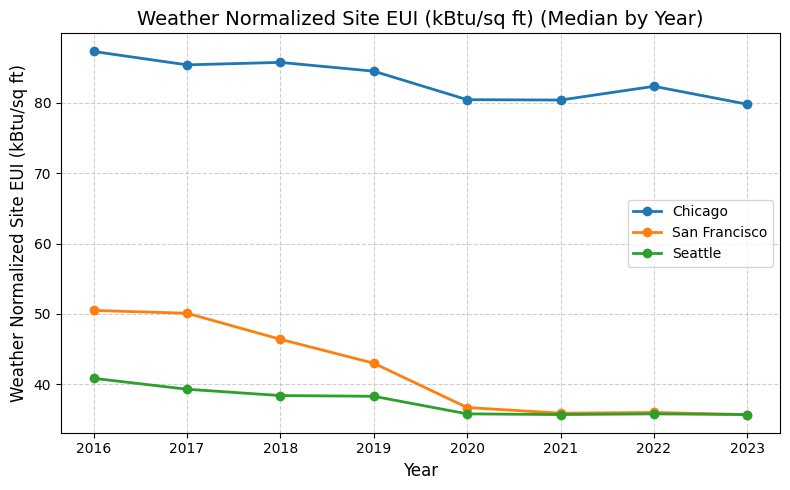

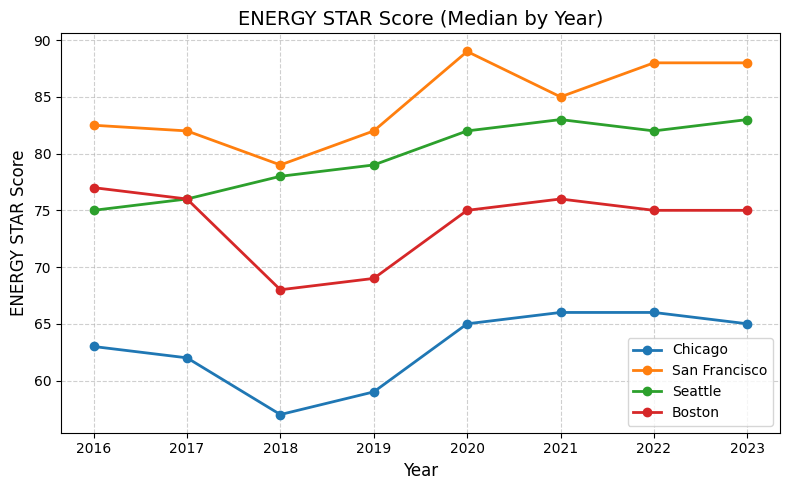

In [134]:
metrics = [
    "Site EUI (kBtu/sq ft)",
    "Weather Normalized Site EUI (kBtu/sq ft)",
    "ENERGY STAR Score",
]

city_dfs = {
    "Chicago": concurrent_df,
    "San Francisco": sf_chi,
    "Seattle": sea_chi,
    "Boston": bos_chi,
}

for metric in metrics:
    df_combined = pd.DataFrame()

    for city, df in city_dfs.items():
        if metric not in df.columns:
            continue

        tmp = df.copy()
        tmp[metric] = pd.to_numeric(tmp[metric], errors="coerce")
        tmp["Data Year"] = pd.to_numeric(tmp["Data Year"], errors="coerce")

        city_series = tmp.groupby("Data Year")[metric].median().dropna()
        if not city_series.empty:
            df_combined[city] = city_series

    df_combined = df_combined.reset_index()

    value_cols = [c for c in df_combined.columns if c != "Data Year"]
    if not value_cols:
        print(f"Skipping {metric} (no usable values).")
        continue

    pu.plot_multi_line_trend(
        df=df_combined,
        year_col="Data Year",
        value_cols=value_cols,
        title=f"{metric} (Median by Year)",
        ylabel=metric,
    )

In [136]:
city_dfs = {
    "Chicago": concurrent_df.copy(),
    "San Francisco": sf_chi.copy(),
    "Seattle": sea_chi.copy(),
    "Boston": bos_chi.copy(),
}

for city, df in city_dfs.items():
    if "Primary Property Type" in df.columns:
        s = df["Primary Property Type"].astype(str).str.strip().str.lower()

        if city == "Seattle":
            s = s.replace(
                {
                    "multifamily hr (10+)": "multifamily housing",
                    "multifamily mr (5-9)": "multifamily housing",
                    "multifamily lr (1-4)": "multifamily housing",
                }
            )

        df["Primary Property Type"] = s

    city_dfs[city] = df

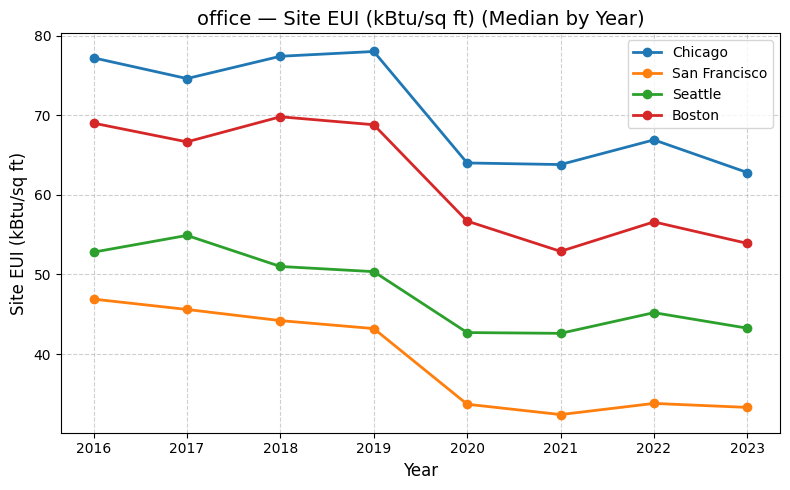

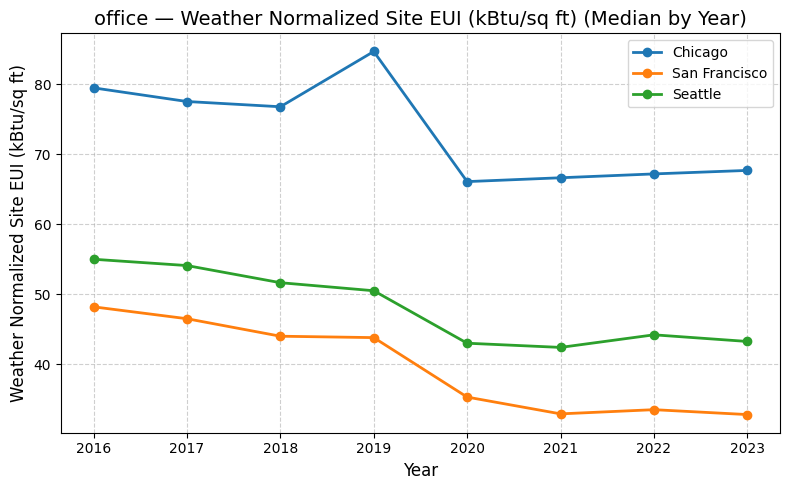

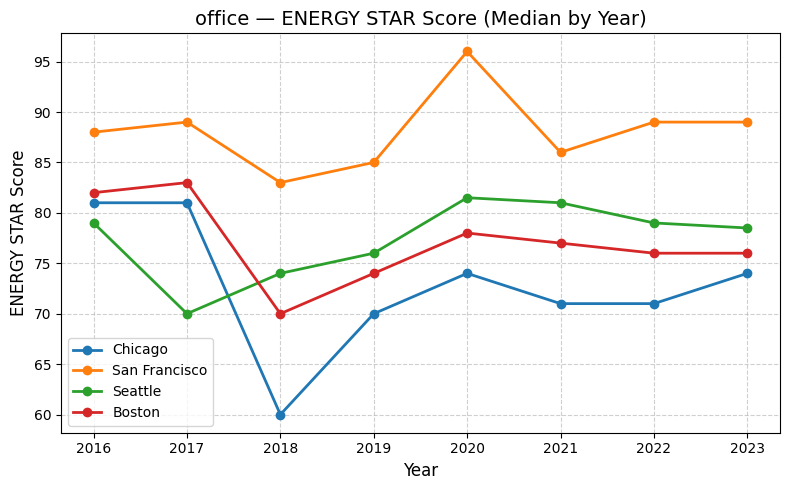

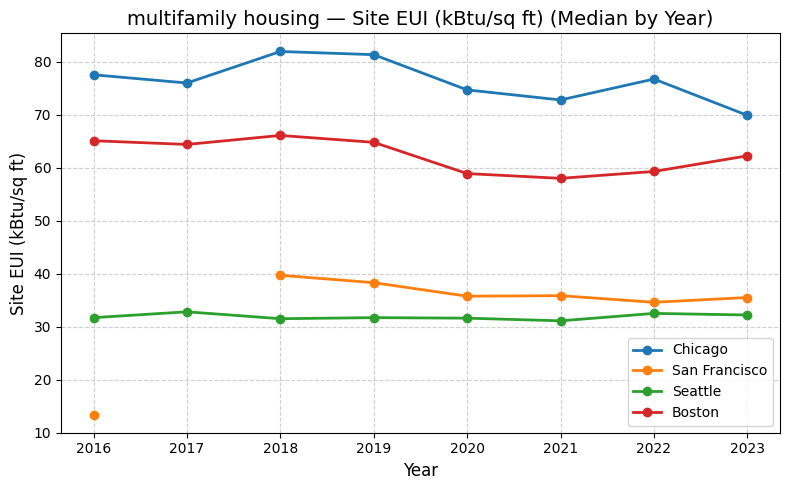

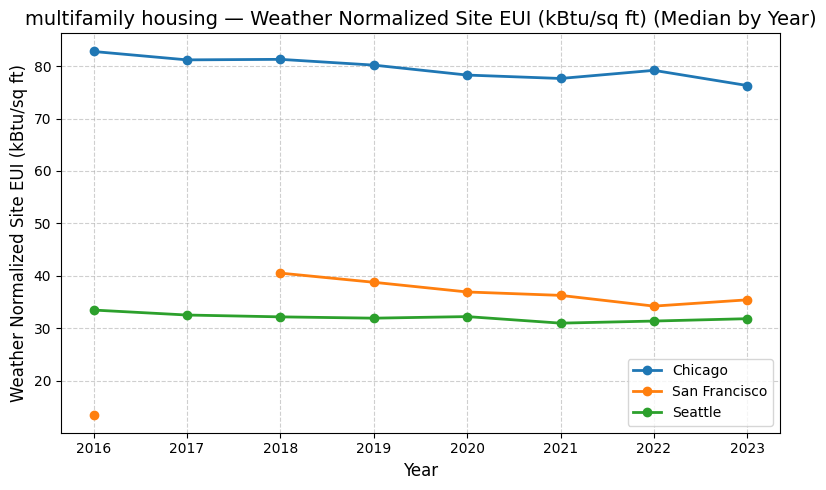

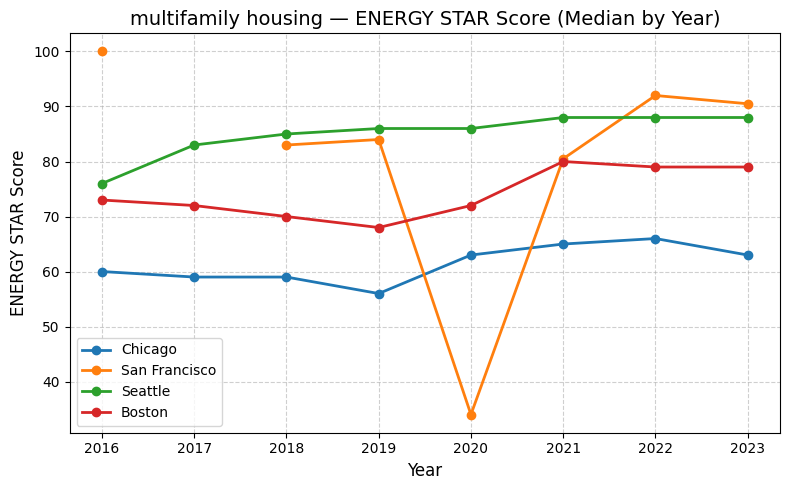

In [137]:
metrics = [
    "Site EUI (kBtu/sq ft)",
    "Weather Normalized Site EUI (kBtu/sq ft)",
    "ENERGY STAR Score",
]

keep_types = ["office", "multifamily housing"]

for btype in keep_types:
    for metric in metrics:
        df_combined = pd.DataFrame()

        for city, df in city_dfs.items():
            if (
                "Primary Property Type" not in df.columns
                or "Data Year" not in df.columns
                or metric not in df.columns
            ):
                continue

            tmp = df[df["Primary Property Type"] == btype].copy()
            tmp["Data Year"] = pd.to_numeric(tmp["Data Year"], errors="coerce")
            tmp[metric] = pd.to_numeric(tmp[metric], errors="coerce")

            s = tmp.groupby("Data Year")[metric].median().dropna()
            if not s.empty:
                df_combined[city] = s

        df_combined = df_combined.reset_index()
        value_cols = [c for c in df_combined.columns if c != "Data Year"]
        if not value_cols:
            print(f"SKIP (no data): {btype} | {metric}")
            continue

        fig, ax = pu.plot_multi_line_trend(
            df=df_combined.sort_values("Data Year"),
            year_col="Data Year",
            value_cols=value_cols,
            title=f"{btype} — {metric} (Median by Year)",
            ylabel=metric,
        )
        plt.show()